In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("bank_nifty_sql.csv")
df.head()

,Instrument,Date,Time,Open,High,Low,Close,daily return%,volatility
0,Banknifty,01-01-2000,00:00:00,1000.00,1000.00,1000.00,1000.00,0.0,0.0
1,Banknifty,03-01-2000,00:00:00,1054.81,1054.81,1054.81,1054.81,0.0,0.0
2,Banknifty,04-01-2000,00:00:00,1092.08,1092.08,1092.08,1092.08,0.0,0.0
3,Banknifty,05-01-2000,00:00:00,1055.99,1055.99,1055.99,1055.99,0.0,0.0
4,Banknifty,06-01-2000,00:00:00,1086.67,1086.67,1086.67,1086.67,0.0,0.0


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6030 entries, 0 to 6029
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Instrument     6030 non-null   object 
 1   Date           6030 non-null   object 
 2   Time           6030 non-null   object 
 3   Open           6030 non-null   float64
 4   High           6030 non-null   float64
 5   Low            6030 non-null   float64
 6   Close          6030 non-null   float64
 7   daily return%  6030 non-null   float64
 8   volatility     6030 non-null   float64
dtypes: float64(6), object(3)
memory usage: 424.1+ KB


,Open,High,Low,Close,daily return%,volatility
count,6030.000000,6030.000000,6030.000000,6030.000000,6030.000000,6030.000000
mean,14894.240638,15009.677935,14760.668464,14886.532036,-0.000263,249.009471
std,12913.844919,12992.302209,12818.432432,12906.976186,0.013785,264.651457
min,743.700000,743.700000,743.700000,743.700000,-0.096369,0.000000
25%,4179.100000,4257.737500,4098.287500,4179.750000,-0.005104,71.275000
50%,10671.750000,10772.575000,10550.475000,10664.675000,0.000000,192.975000
75%,24101.737500,24258.037500,23913.375000,24091.225000,0.004396,344.462500
max,48879.550000,49057.400000,48669.250000,48986.600000,0.107642,4319.050000


In [14]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

In [10]:
df['daily_return'] = df['Close'].pct_change() * 100
df['volatility'] = df['daily_return'].rolling(20).std()
df['range'] = df['High'] - df['Low']

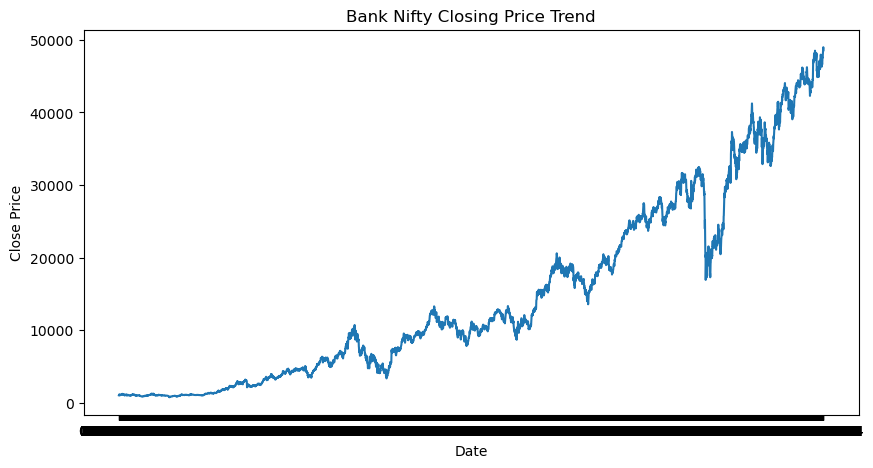

In [13]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'])
plt.title('Bank Nifty Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

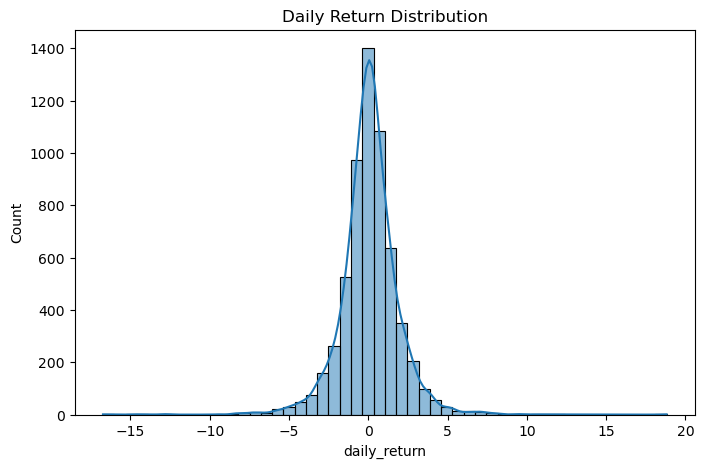

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['daily_return'].dropna(), bins=50, kde=True)
plt.title('Daily Return Distribution')
plt.show()

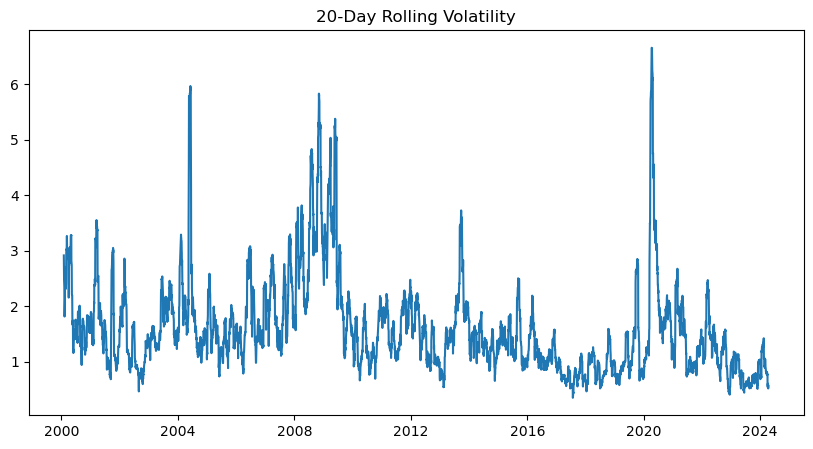

In [16]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['volatility'])
plt.title('20-Day Rolling Volatility')
plt.show()